In [7]:
import numpy as np
import matplotlib.pyplot as plt

Probabilidade Estimada: 0.7774


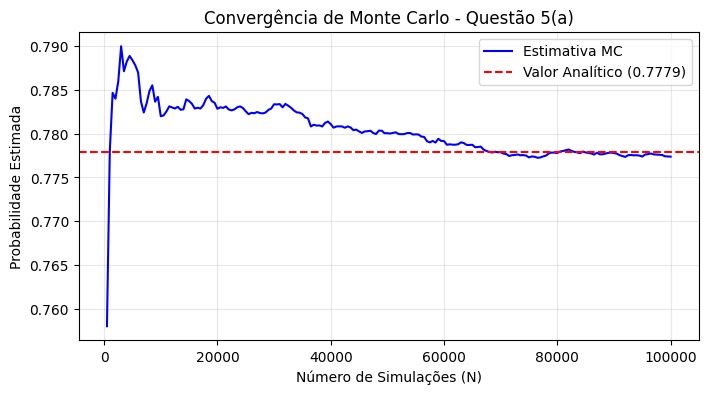

In [8]:
#(a) Qual é a probabilidade de obter pelo menos uma carta do tipo B e uma do tipo D?
# Parâmetros
N_simulacoes = 100000
baralho = np.array(['A']*12 + ['B']*12 + ['C']*12 + ['D']*12)
sucessos = 0
estimativas = []

# Processo de Simulação
for i in range(1, N_simulacoes + 1):
    # Sorteio sem reposição (replace=False)
    amostra = np.random.choice(baralho, 7, replace=False)
    
    # Verificação do evento "pelo menos uma carta B e uma carta D"
    if 'B' in amostra and 'D' in amostra:
        sucessos += 1
    
    # Guardar evolução para o gráfico a cada 500 simulações
    if i % 500 == 0:
        estimativas.append(sucessos / i)

# Resultado Final da Simulação
print(f"Probabilidade Estimada: {sucessos/N_simulacoes:.4f}")


#Grafico da evolução da estimativa
plt.figure(figsize=(8, 4))
plt.plot(range(500, N_simulacoes + 1, 500), estimativas, color='blue', label='Estimativa MC')
plt.axhline(y=0.7779, color='red', linestyle='--', label='Valor Analítico (0.7779)')
plt.title('Convergência de Monte Carlo - Questão 5(a)')
plt.xlabel('Número de Simulações (N)')
plt.ylabel('Probabilidade Estimada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Probabilidade Estimada final: 0.7404


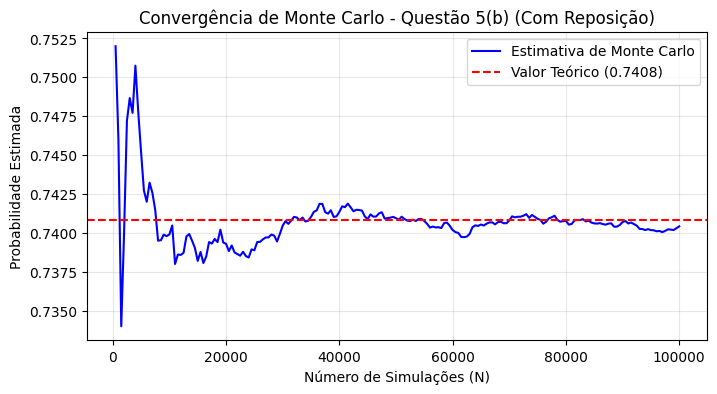

In [ ]:
#b) Refaça o cálculo supondo que as cartas sejam retiradas com reposição

# Parâmetros do problema
N_simulacoes = 100000
baralho = np.array(['A']*12 + ['B']*12 + ['C']*12 + ['D']*12)
valor_teorico = 0.7408
sucessos = 0
historico_prob = []

# Processo de Monte Carlo
for i in range(1, N_simulacoes + 1):
    amostra = np.random.choice(baralho, 7, replace=True)
    
    # Verifica se há pelo menos uma carta B e uma carta D
    if 'B' in amostra and 'D' in amostra:
        sucessos += 1
    
    # Armazena a evolução para o gráfico a cada 500 passos
    if i % 500 == 0:
        historico_prob.append(sucessos / i)

print(f"Probabilidade Estimada final: {sucessos/N_simulacoes:.4f}")

#Gráfico de Convergência
plt.figure(figsize=(8, 4))
eixo_x = range(500, N_simulacoes + 1, 500)

plt.plot(eixo_x, historico_prob, color='blue', label='Estimativa de Monte Carlo')
plt.axhline(y=valor_teorico, color='red', linestyle='--', label=f'Valor Teórico ({valor_teorico})')

plt.title('Convergência de Monte Carlo - Questão 5(b) (Com Reposição)')
plt.xlabel('Número de Simulações (N)')
plt.ylabel('Probabilidade Estimada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Probabilidade Estimada (Sem Reposição): 0.7847
Probabilidade Estimada (Com Reposição): 0.7504


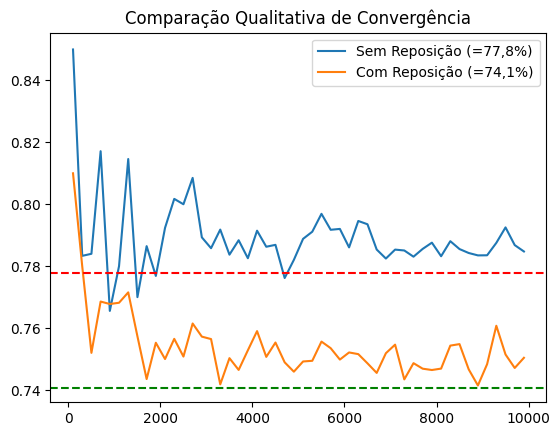

In [ ]:
#c) Explique qualitativamente a diferença entre os dois resultados
import matplotlib.pyplot as plt

n_testes = np.arange(100, 10001, 200)
res_sem, res_com = [], []
for n in n_testes:
    s_sem = sum(['B' in np.random.choice(baralho, 7, False) and 'D' in np.random.choice(baralho, 7, False) for _ in range(n)])
    s_com = sum(['B' in np.random.choice(baralho, 7, True) and 'D' in np.random.choice(baralho, 7, True) for _ in range(n)])
    res_sem.append(s_sem/n); res_com.append(s_com/n)
print(f"Probabilidade Estimada (Sem Reposição): {res_sem[-1]:.4f}")
print(f"Probabilidade Estimada (Com Reposição): {res_com[-1]:.4f}")

plt.plot(n_testes, res_sem, label='Sem Reposição (=77,8%)')
plt.plot(n_testes, res_com, label='Com Reposição (=74,1%)')
plt.axhline(y=0.7779, color='red', linestyle='--'); plt.axhline(y=0.7408, color='green', linestyle='--')
plt.title("Comparação Qualitativa de Convergência")
plt.legend(); plt.show()